In [106]:
from pickle import load
from pathlib import Path

In [108]:
!ls artifacts

boosted_tree_stack_week_1.pkl  boosted_tree_stack_week_8.pkl
boosted_tree_stack_week_10.pkl boosted_tree_stack_week_9.pkl
boosted_tree_stack_week_11.pkl city_name_encoder.pkl
boosted_tree_stack_week_12.pkl encoders
boosted_tree_stack_week_2.pkl  meal_info_encoder.pkl
boosted_tree_stack_week_3.pkl  meal_name_encoder.pkl
boosted_tree_stack_week_4.pkl  models
boosted_tree_stack_week_5.pkl  price_scaler_encoder.pkl
boosted_tree_stack_week_6.pkl  tuned-model
boosted_tree_stack_week_7.pkl  tuned-params


In [183]:
def load_model(model_name, artifact_path='artifacts'):
    with open(Path(artifact_path)/model_name, mode='rb') as f:
        model = load(f)
    return model

In [185]:
import pandas as pd

In [187]:
!ls data

final_week_processed.csv   meal_demand_historical.csv
full_clean_encoded.csv     train_processed.csv


In [193]:
df_final_week = pd.read_csv("data/final_week_processed.csv")

In [195]:
df_final_week

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,quarter_num,week_of_year,week_sin,week_cos,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks
0,145,0.711608,0.530610,0.0,0.0,26.0,3.4,0,0,0,...,4,41,-0.970942,0.239316,14.0,0.0,9.75,10.1875,14.00,14.6250
1,145,0.015750,-0.121236,0.0,0.0,107.0,4.0,0,0,1,...,4,41,-0.970942,0.239316,96.0,53.0,87.50,132.0000,154.75,177.8125
2,145,-0.622619,-0.145192,1.0,0.0,14.0,2.8,0,0,0,...,4,41,-0.970942,0.239316,0.0,27.0,10.25,14.6250,41.25,17.1250
3,145,-0.331983,-0.446972,0.0,0.0,553.0,3.4,0,0,1,...,4,41,-0.970942,0.239316,405.0,620.0,654.50,859.9375,496.50,553.8750
4,145,-0.401334,-0.525622,0.0,0.0,487.0,5.1,0,0,1,...,4,41,-0.970942,0.239316,418.0,513.0,540.25,681.9375,398.75,353.2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3179,145,2.538592,2.280939,0.0,0.0,14.0,4.8,0,1,0,...,4,41,-0.970942,0.239316,202.0,26.0,40.50,27.7500,149.00,86.3125
3180,145,-0.938935,-1.032614,0.0,0.0,54.0,4.5,0,0,0,...,4,41,-0.970942,0.239316,69.0,69.0,68.50,72.1250,44.00,59.0625
3181,145,-0.129665,-0.260055,0.0,0.0,366.0,4.5,1,0,0,...,4,41,-0.970942,0.239316,446.0,352.0,385.25,440.0625,163.00,488.8750
3182,145,0.142199,0.011921,0.0,0.0,202.0,3.8,0,0,1,...,4,41,-0.970942,0.239316,378.0,352.0,276.75,270.1250,270.50,282.4375


In [197]:
df_final_week[df_final_week.isnull().any(axis=1)]

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,Meat,Other,Seafood,...,quarter_num,week_of_year,week_sin,week_cos,num_orders_last_year,num_orders_last_week,num_orders_rolling_4_week,num_orders_rolling_16_week,num_orders_last_year_rolling_4_weeks,num_orders_last_year_rolling_16_weeks


In [199]:
from tqdm import tqdm

In [201]:
df_final_week.columns

Index(['week_number', 'checkout_price', 'base_price', 'emailer_for_promotion',
       'homepage_featured', 'num_orders', 'op_area', 'Meat', 'Other',
       'Seafood', 'Vegetarian', 'beverage', 'dessert', 'main', 'side',
       'starter', 'city_id', 'meal_id', 'price_diff', 'year_num', 'month_num',
       'quarter_num', 'week_of_year', 'week_sin', 'week_cos',
       'num_orders_last_year', 'num_orders_last_week',
       'num_orders_rolling_4_week', 'num_orders_rolling_16_week',
       'num_orders_last_year_rolling_4_weeks',
       'num_orders_last_year_rolling_16_weeks'],
      dtype='object')

In [205]:
def predict_demand(df_week_x, future_weeks=12):
    initial_week = df_week_x.week_number.max()
    city_ids = df_week_x.city_id.values
    meal_ids = df_week_x.meal_id.values
    meal_infos = df_week_x[['Meat', 'Other',
       'Seafood', 'Vegetarian', 'beverage', 'dessert', 'main', 'side',
       'starter']].values
    y_preds = []
  
    for future_week_offset in tqdm(range(1, future_weeks+1)):
        pred_week_num = initial_week + future_week_offset
        print(f"Prediction for week {pred_week_num}")
        model = load_model(f"boosted_tree_stack_week_{future_week_offset}.pkl")
        y_pred = model.predict(df_week_x)
        y_preds.extend([{
            "period": "Future",
            "week_number": pred_week_num,
            "num_orders": y,
            "city_id": city_id,
            "meal_id": meal_id,
            "meal_info": meal_info
        } for y, city_id, meal_id, meal_info in zip(y_pred, city_ids, meal_ids, meal_infos)])

    df_preds = pd.DataFrame(y_preds)
    return df_preds

df_future = predict_demand(df_final_week)
df_future

100%|███████████████████████████████████████████| 12/12 [00:00<00:00, 63.63it/s]


Prediction for week 146
Prediction for week 147
Prediction for week 148
Prediction for week 149
Prediction for week 150
Prediction for week 151
Prediction for week 152
Prediction for week 153
Prediction for week 154
Prediction for week 155
Prediction for week 156
Prediction for week 157


,period,week_number,num_orders,city_id,meal_id,meal_info
0,Future,146,6.053620,48,3,"[0, 0, 0, 1, 0, 0, 0, 1, 0]"
1,Future,146,108.895752,37,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
2,Future,146,39.971783,14,11,"[0, 0, 0, 1, 0, 0, 0, 1, 0]"
3,Future,146,588.305786,48,47,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
4,Future,146,532.297058,53,47,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
...,...,...,...,...,...,...
38203,Future,157,75.685013,41,16,"[0, 1, 0, 0, 1, 0, 0, 0, 0]"
38204,Future,157,94.904549,68,9,"[0, 0, 0, 1, 0, 0, 0, 0, 1]"
38205,Future,157,491.499237,64,49,"[1, 0, 0, 0, 0, 0, 1, 0, 0]"
38206,Future,157,253.441406,42,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"


In [207]:
import numpy as np

In [209]:
class OrderedCategoryEncoder:
    def __init__(self):
        self.categories_: list[str] = None
        self.category_map: dict[str: int] = None
        self.inverse_category_map: dict[int: str] = None

    def fit(self, ordered_categories: list[str]):
        self.categories_ = ordered_categories
        self.category_map = {category: i+1 for i, category in enumerate(ordered_categories)}
        self.inverse_category_map = {i+1: category for i, category in enumerate(ordered_categories)}


    def transform(self, values: list[str]) -> np.array:
        if set(values) - set(self.categories_):
            for value in values:
                print(f"{value} was not in the fit data")
            raise ValueError("New category found, cannot transform")
        return np.array([self.category_map[value] for value in values])

    def inverse_transform(self, values: list[str]) -> np.array:
        return np.array([self.inverse_category_map[value] for value in values])
    

In [211]:
import re

def load_encoders(artifact_path='artifacts'):
    encoders = {}
    for file_path in Path(artifact_path).glob("*encoder.pkl"):
        print(file_path)
        with open(file_path, 'rb') as f:
            print(file_path.name)
            encoders[re.findall(r"(.*)_encoder", file_path.name)[0]] = load(f)
    return encoders

encoders = load_encoders()
encoders.keys()

artifacts/meal_name_encoder.pkl
meal_name_encoder.pkl
artifacts/city_name_encoder.pkl
city_name_encoder.pkl
artifacts/price_scaler_encoder.pkl
price_scaler_encoder.pkl
artifacts/meal_info_encoder.pkl
meal_info_encoder.pkl


dict_keys(['meal_name', 'city_name', 'price_scaler', 'meal_info'])

In [213]:
df_future

,period,week_number,num_orders,city_id,meal_id,meal_info
0,Future,146,6.053620,48,3,"[0, 0, 0, 1, 0, 0, 0, 1, 0]"
1,Future,146,108.895752,37,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
2,Future,146,39.971783,14,11,"[0, 0, 0, 1, 0, 0, 0, 1, 0]"
3,Future,146,588.305786,48,47,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
4,Future,146,532.297058,53,47,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
...,...,...,...,...,...,...
38203,Future,157,75.685013,41,16,"[0, 1, 0, 0, 1, 0, 0, 0, 0]"
38204,Future,157,94.904549,68,9,"[0, 0, 0, 1, 0, 0, 0, 0, 1]"
38205,Future,157,491.499237,64,49,"[1, 0, 0, 0, 0, 0, 1, 0, 0]"
38206,Future,157,253.441406,42,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"


In [215]:
df_past = pd.read_csv("data/full_clean_encoded.csv")

In [216]:
df_past['period'] = 'past'

In [219]:
df_past['meal_info'] = [item for item in df_past[['Meat', 'Other','Seafood', 'Vegetarian', 
                                'beverage', 'dessert', 'main', 'side','starter']].values]

In [221]:
columns = ['period','week_number','num_orders','city_id','meal_id', 'meal_info']

df = pd.concat([df_past[columns], df_future[columns]], axis=0, ignore_index=True)

In [223]:
df

,period,week_number,num_orders,city_id,meal_id,meal_info
0,past,27,256.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]"
1,past,28,122.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]"
2,past,29,163.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]"
3,past,30,284.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]"
4,past,31,189.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]"
...,...,...,...,...,...,...
528569,Future,157,75.685013,41,16,"[0, 1, 0, 0, 1, 0, 0, 0, 0]"
528570,Future,157,94.904549,68,9,"[0, 0, 0, 1, 0, 0, 0, 0, 1]"
528571,Future,157,491.499237,64,49,"[1, 0, 0, 0, 0, 0, 1, 0, 0]"
528572,Future,157,253.441406,42,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"


In [225]:
df['current_week'] = 146

In [227]:
df

,period,week_number,num_orders,city_id,meal_id,meal_info,current_week
0,past,27,256.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146
1,past,28,122.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146
2,past,29,163.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146
3,past,30,284.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146
4,past,31,189.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146
...,...,...,...,...,...,...,...
528569,Future,157,75.685013,41,16,"[0, 1, 0, 0, 1, 0, 0, 0, 0]",146
528570,Future,157,94.904549,68,9,"[0, 0, 0, 1, 0, 0, 0, 0, 1]",146
528571,Future,157,491.499237,64,49,"[1, 0, 0, 0, 0, 0, 1, 0, 0]",146
528572,Future,157,253.441406,42,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]",146


In [229]:
df['meal_name'] = encoders['meal_name'].inverse_transform(df.meal_id)
df['city_name'] = encoders['city_name'].inverse_transform(df.city_id)

In [230]:
df

,period,week_number,num_orders,city_id,meal_id,meal_info,current_week,meal_name,city_name
0,past,27,256.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146,Apple and Raisin Bread,Aldershade
1,past,28,122.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146,Apple and Raisin Bread,Aldershade
2,past,29,163.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146,Apple and Raisin Bread,Aldershade
3,past,30,284.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146,Apple and Raisin Bread,Aldershade
4,past,31,189.000000,70,39,"[0, 1, 0, 0, 0, 1, 0, 0, 0]",146,Apple and Raisin Bread,Aldershade
...,...,...,...,...,...,...,...,...,...
528569,Future,157,75.685013,41,16,"[0, 1, 0, 0, 1, 0, 0, 0, 0]",146,Goblin Brew,Nightfall
528570,Future,157,94.904549,68,9,"[0, 0, 0, 1, 0, 0, 0, 0, 1]",146,Goat Cheese and Spinach Salad,Thornfield
528571,Future,157,491.499237,64,49,"[1, 0, 0, 0, 0, 0, 1, 0, 0]",146,Braised Oxen Tail,Driftwood
528572,Future,157,253.441406,42,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]",146,Pan-Seared Salmon,Hollowcrest


In [233]:
df[['meal_category', 'meal_type']] = encoders['meal_info'].inverse_transform(df['meal_info'].values.tolist())

df.drop(columns=['meal_info'], inplace=True)

df.drop(columns=['city_id', 'meal_id'], inplace=True)

In [235]:
df

,period,week_number,num_orders,current_week,meal_name,city_name,meal_category,meal_type
0,past,27,256.000000,146,Apple and Raisin Bread,Aldershade,Other,dessert
1,past,28,122.000000,146,Apple and Raisin Bread,Aldershade,Other,dessert
2,past,29,163.000000,146,Apple and Raisin Bread,Aldershade,Other,dessert
3,past,30,284.000000,146,Apple and Raisin Bread,Aldershade,Other,dessert
4,past,31,189.000000,146,Apple and Raisin Bread,Aldershade,Other,dessert
...,...,...,...,...,...,...,...,...
528569,Future,157,75.685013,146,Goblin Brew,Nightfall,Other,beverage
528570,Future,157,94.904549,146,Goat Cheese and Spinach Salad,Thornfield,Vegetarian,starter
528571,Future,157,491.499237,146,Braised Oxen Tail,Driftwood,Meat,main
528572,Future,157,253.441406,146,Pan-Seared Salmon,Hollowcrest,Seafood,main


### Visualize forecast:

In [238]:
df.groupby(['week_number', 'period']).num_orders.sum().unstack()

period,Future,past
week_number,,
1,NaN,772831.0
2,NaN,764453.0
3,NaN,672482.0
4,NaN,721741.0
5,NaN,920320.0
...,...,...
153,778282.027733,NaN
154,734290.898860,NaN
155,578350.482204,NaN


In [240]:
df.groupby(['week_number', 'period']).num_orders.sum().unstack().iloc[140:150, :]

period,Future,past
week_number,,
141,NaN,751091.0
142,NaN,712482.0
143,NaN,734884.0
144,NaN,776674.0
145,NaN,648256.0
146,621650.230073,NaN
147,661835.424483,NaN
148,638643.746167,NaN
149,538809.703999,NaN


<Axes: xlabel='week_number'>

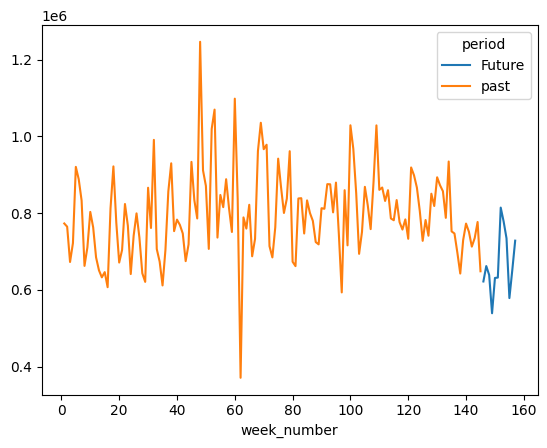

In [242]:
df.groupby(['week_number', 'period']).num_orders.sum().unstack().plot()

In [244]:
df_future

,period,week_number,num_orders,city_id,meal_id,meal_info
0,Future,146,6.053620,48,3,"[0, 0, 0, 1, 0, 0, 0, 1, 0]"
1,Future,146,108.895752,37,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
2,Future,146,39.971783,14,11,"[0, 0, 0, 1, 0, 0, 0, 1, 0]"
3,Future,146,588.305786,48,47,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
4,Future,146,532.297058,53,47,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"
...,...,...,...,...,...,...
38203,Future,157,75.685013,41,16,"[0, 1, 0, 0, 1, 0, 0, 0, 0]"
38204,Future,157,94.904549,68,9,"[0, 0, 0, 1, 0, 0, 0, 0, 1]"
38205,Future,157,491.499237,64,49,"[1, 0, 0, 0, 0, 0, 1, 0, 0]"
38206,Future,157,253.441406,42,34,"[0, 0, 1, 0, 0, 0, 1, 0, 0]"


In [246]:
import matplotlib.pyplot as plt

In [248]:
def plot_demand_for_meal(meal_name):
    df[df['meal_name'] == meal_name].groupby(['week_number', 'period']).num_orders.sum().unstack().plot(title=meal_name)
    plt.show()

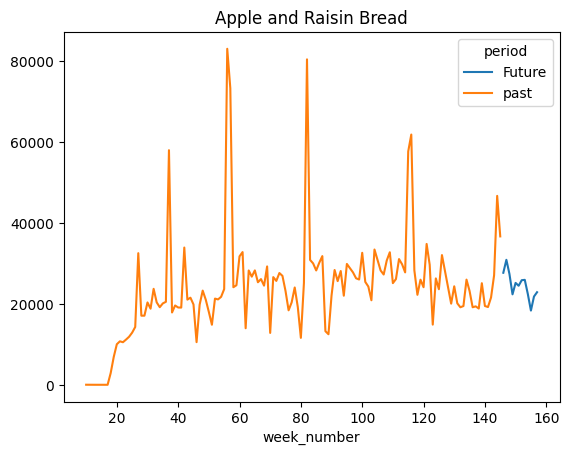

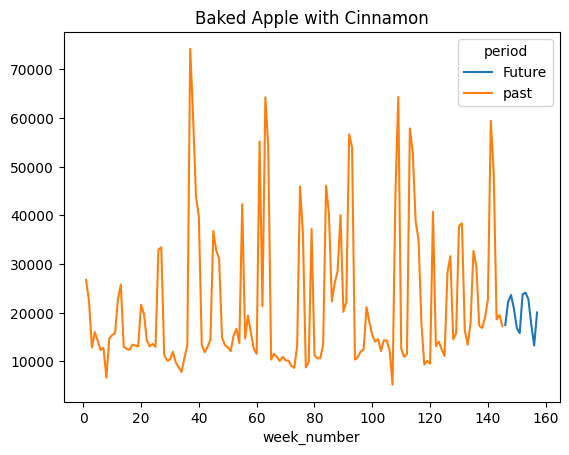

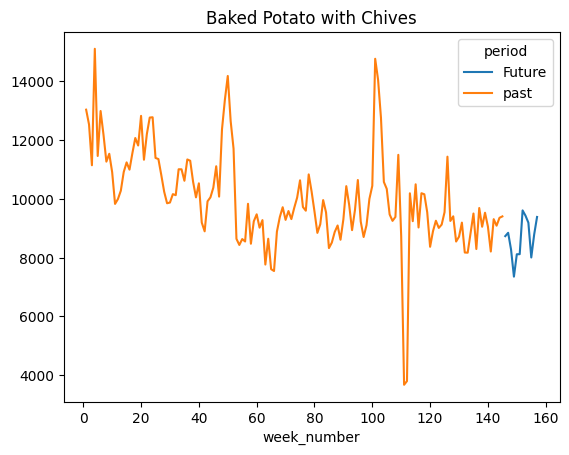

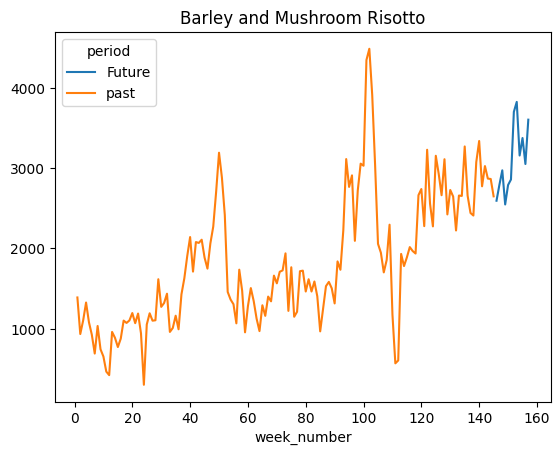

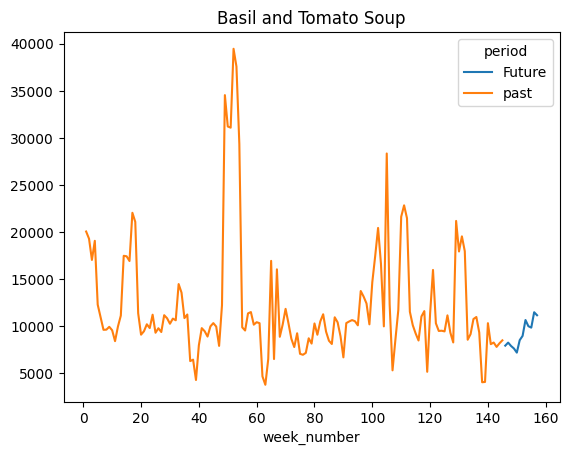

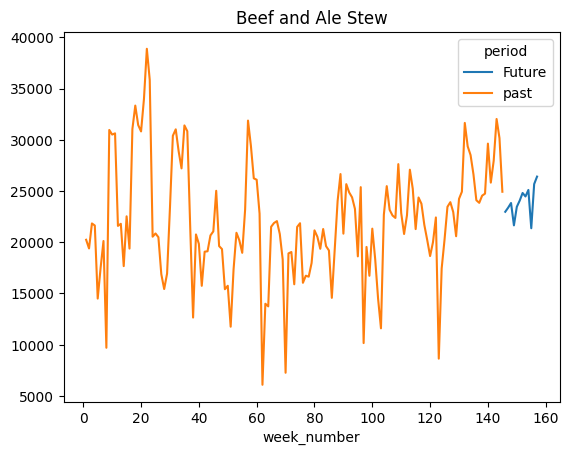

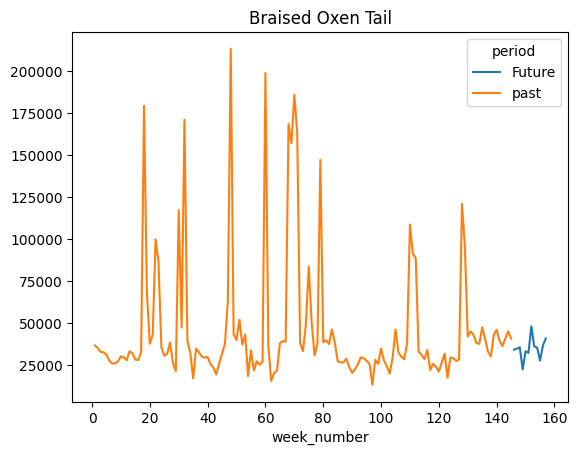

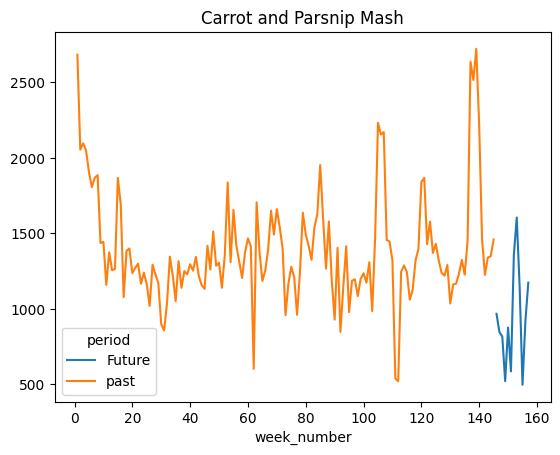

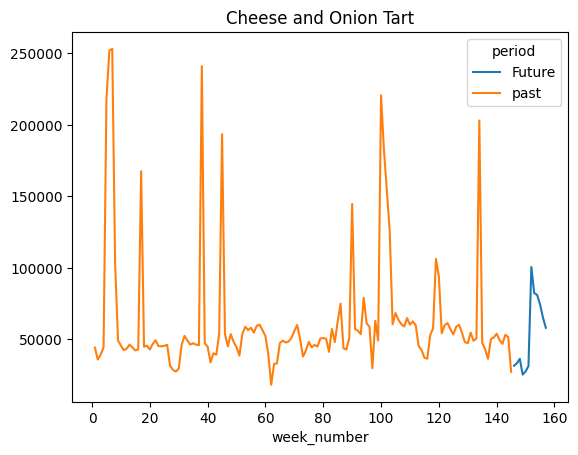

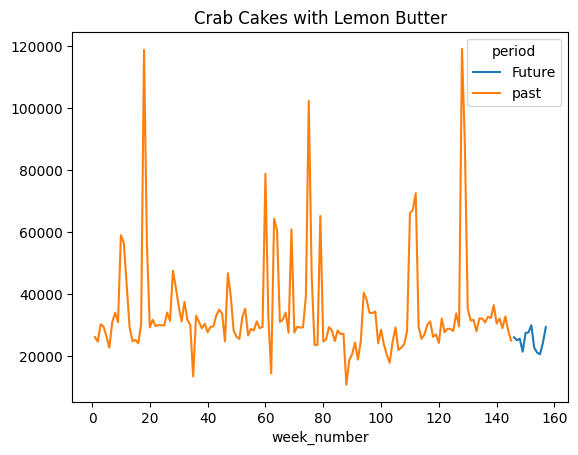

In [250]:
def plot_demand_for_meal(meal_name):
    df[df['meal_name'] == meal_name].groupby(['week_number', 'period']).num_orders.sum().unstack().plot(title=meal_name)
    plt.show()
    
for meal_name in df['meal_name'].unique()[:10]:
    plot_demand_for_meal(meal_name)

In [89]:
def plot_demand_for_meal_segment(segment_name, segment_value):
    df[df[segment_name] == segment_value].groupby(['week_number', 'period']).num_orders.sum()\
                                                        .unstack().plot(title=f"{segment_name}={segment_value}")
    plt.show()

In [92]:
df[['meal_type', 'meal_category']].value_counts().index.tolist()

[('main', 'Meat'),
 ('starter', 'Vegetarian'),
 ('dessert', 'Other'),
 ('starter', 'Other'),
 ('main', 'Vegetarian'),
 ('main', 'Seafood'),
 ('beverage', 'Other'),
 ('side', 'Vegetarian'),
 ('starter', 'Seafood'),
 ('starter', 'Meat')]

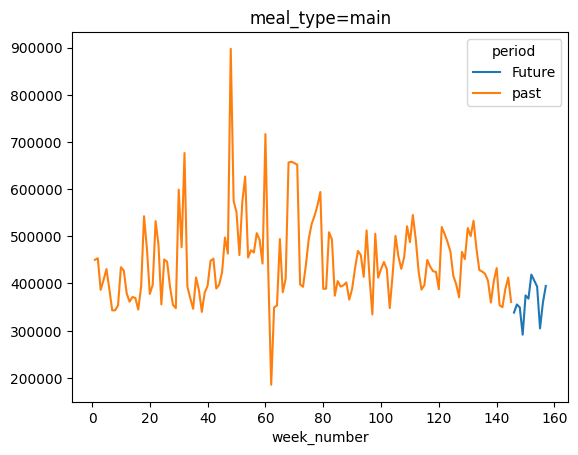

In [94]:
plot_demand_for_meal_segment('meal_type', 'main')

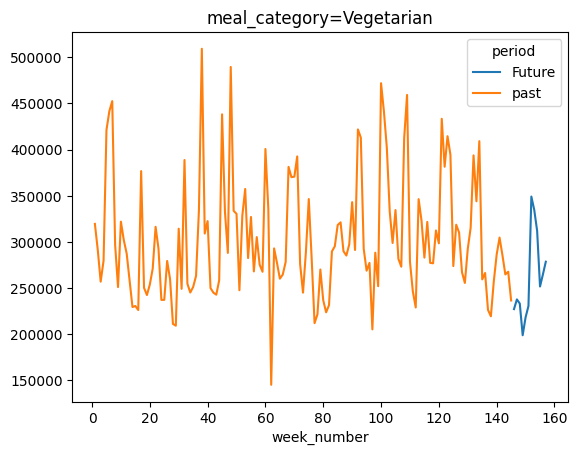

In [95]:
plot_demand_for_meal_segment('meal_category', 'Vegetarian')

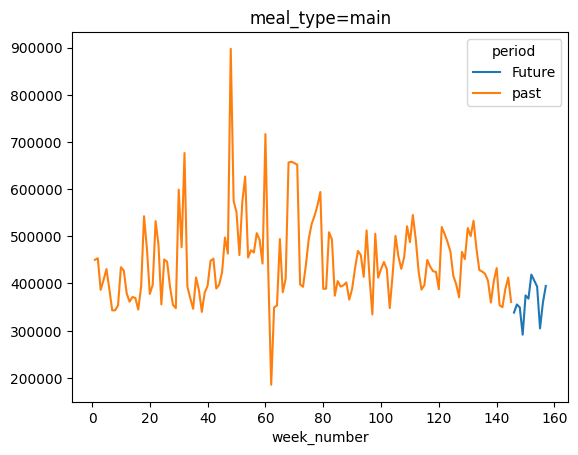

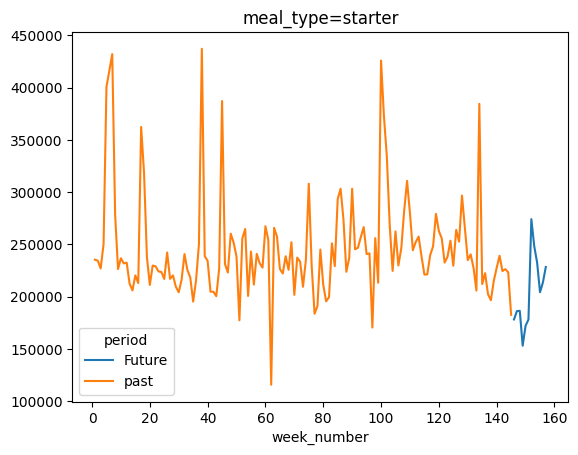

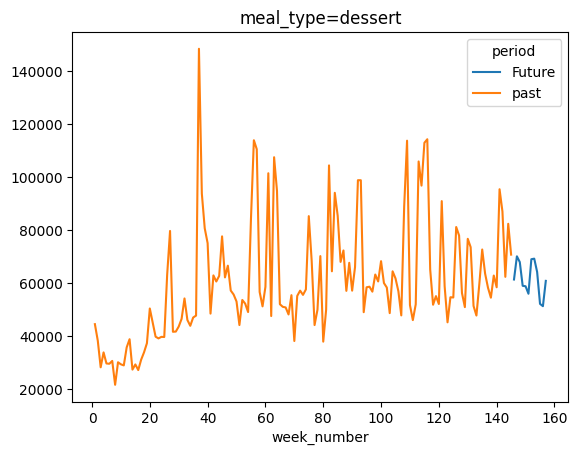

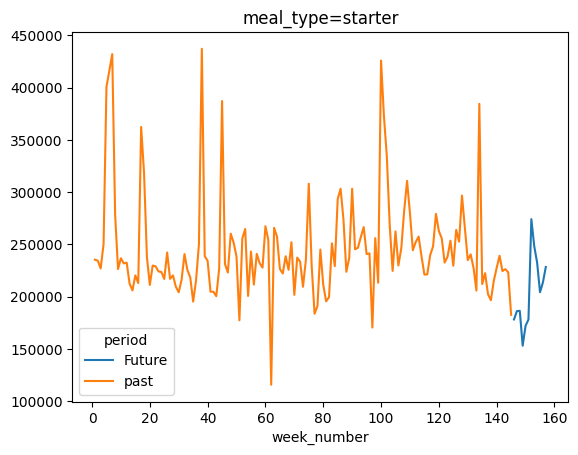

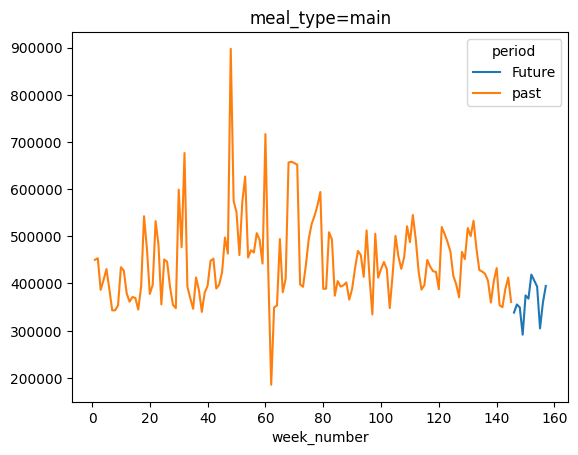

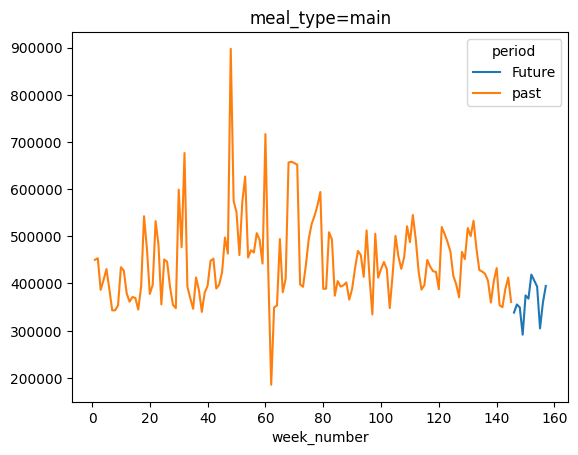

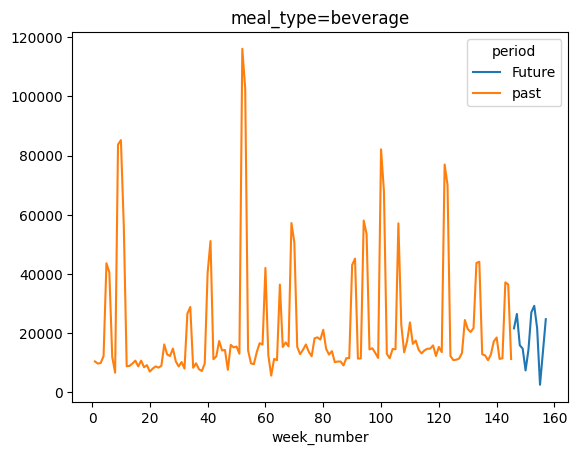

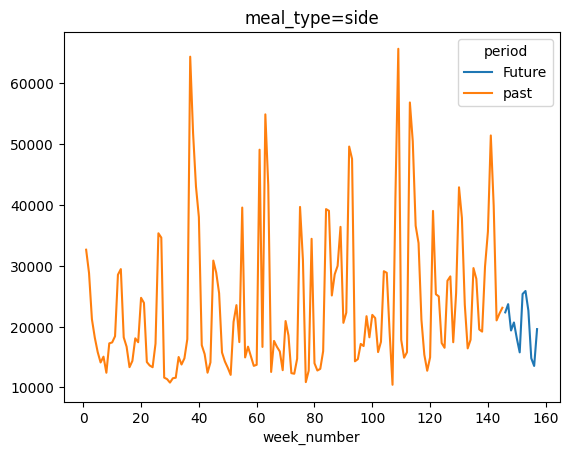

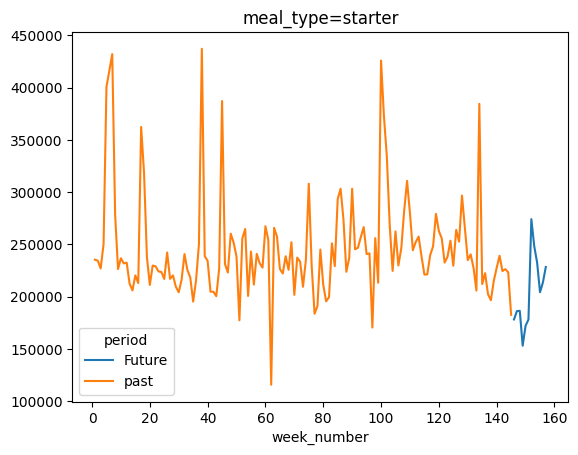

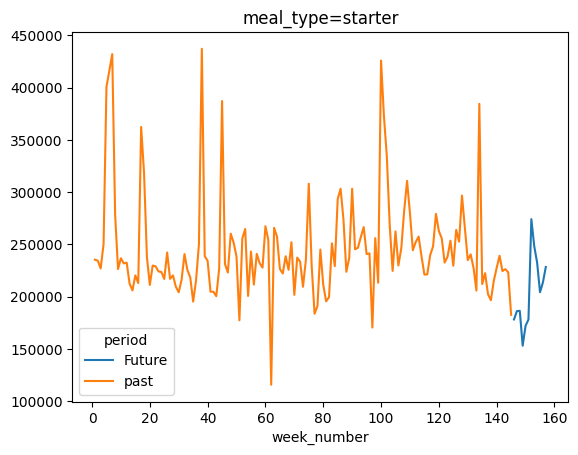

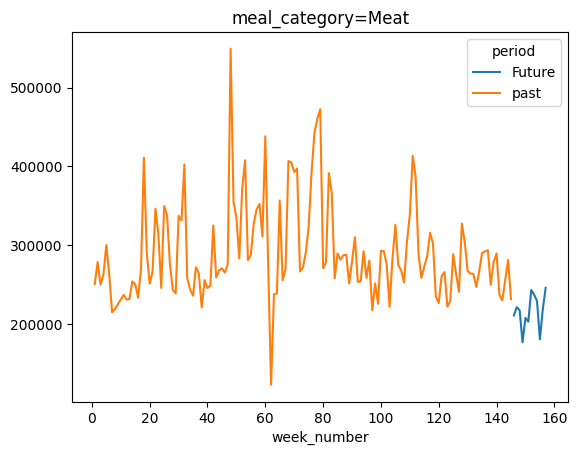

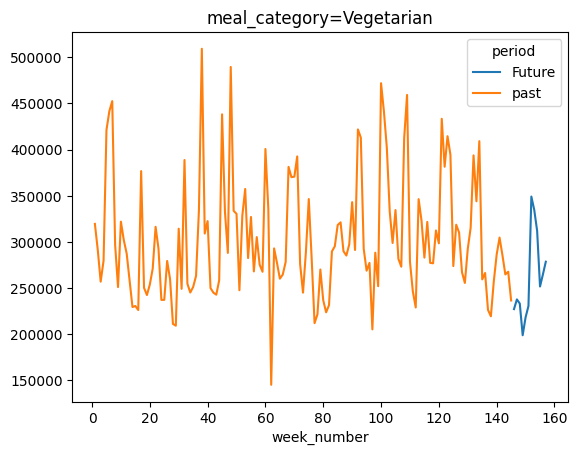

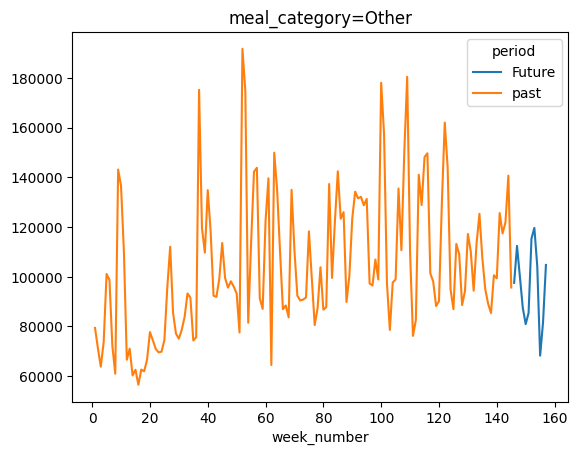

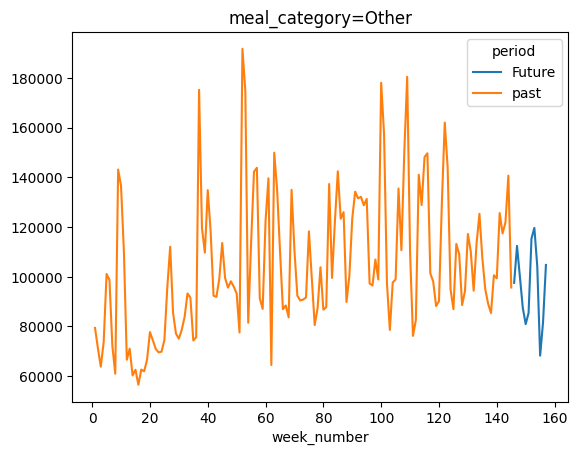

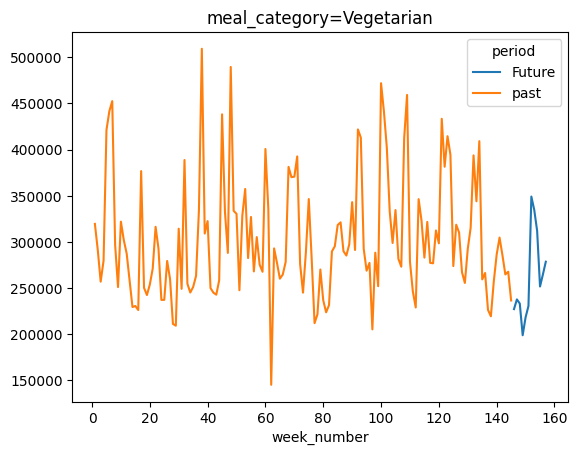

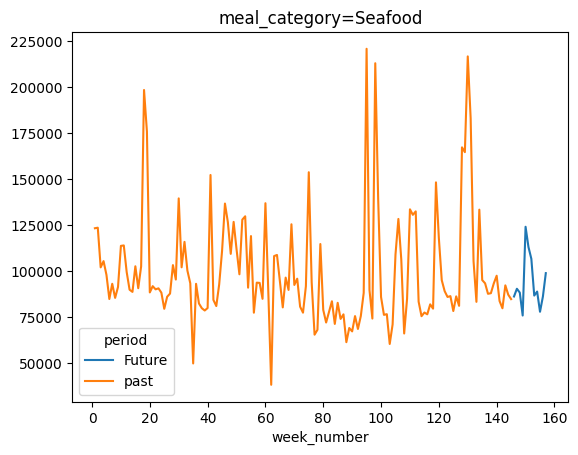

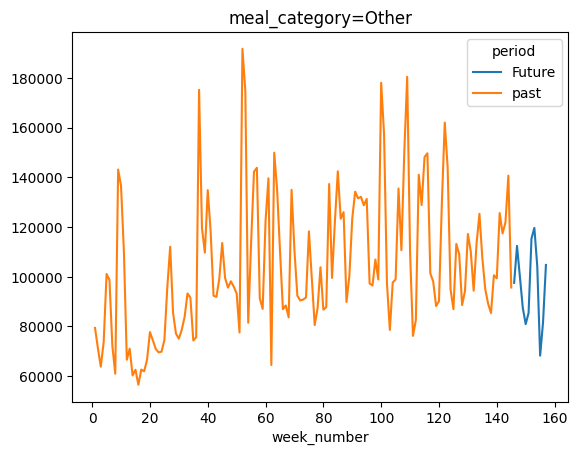

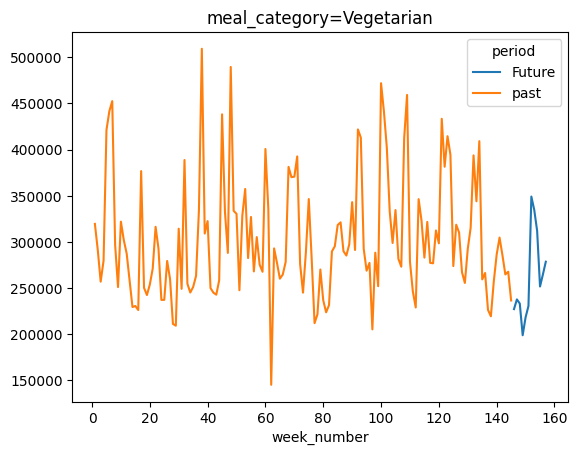

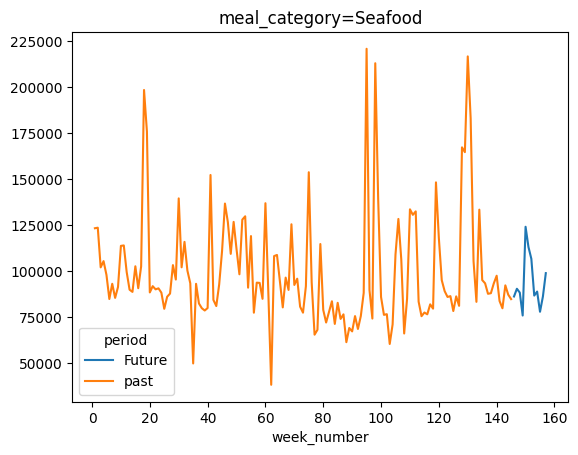

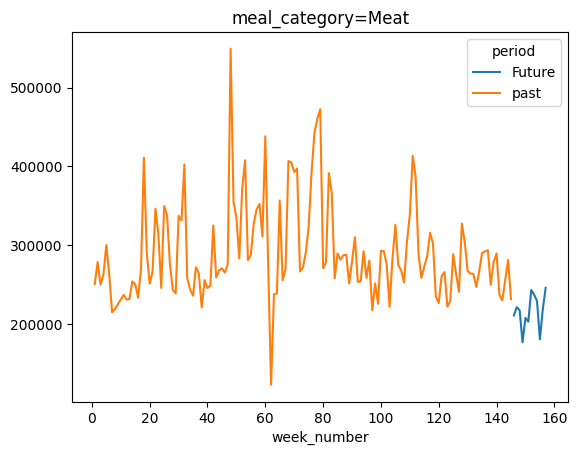

In [98]:
for i in df[['meal_type', 'meal_category']].value_counts().index.tolist():
    plot_demand_for_meal_segment('meal_type', i[0])

for i in df[['meal_type', 'meal_category']].value_counts().index.tolist():
    plot_demand_for_meal_segment('meal_category', i[1])


In [100]:
df.to_csv("postgre_data.csv")

In [5]:
!docker run --name ml-quest-postgres \
    --rm -d \
    -e POSTGRES_HOST_AUTH_METHOD=trust \
    -p 5432:5432 \
    -v postgres_data:/var/lib/postgresql/data \
    postgres:13

33637f3d10857522afcbfa9cd9a395aaba0f4aa1027191fe1885b7a7783b1329


In [15]:
!docker stop ml-quest-postgres

ml-quest-postgres


In [166]:
run_query("""

SELECT current_database(), current_user, current_schema();
SHOW search_path;


""")

,search_path
0,"""$user"", public"


In [7]:
run_query("""

SELECT current_database(), current_user, current_schema();

""")

NameError: name 'run_query' is not defined

In [170]:
run_query("""

SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_name ILIKE '%meal%demand%';

""")

,table_schema,table_name
0,public,current_meal_demand_metadata
1,public,current_meal_demand


In [264]:
df[df["period"] == "Future"].week_number.nunique()

12

In [158]:
run_query("""SELECT current_database(),
       current_user,
       current_schema(),
       inet_server_addr(),
       inet_server_port(),
       version();
       """)

,current_database,current_user,current_schema,inet_server_addr,inet_server_port,version
0,postgres,postgres,public,172.17.0.2,5432,PostgreSQL 13.23 (Debian 13.23-1.pgdg13+1) on ...


In [142]:
!docker ps | grep postgres

596e258e35b2   postgres:13   "docker-entrypoint.s…"   1 second ago    Up Less than a second   0.0.0.0:5432->5432/tcp, [::]:5432->5432/tcp   ml-quest-postgres
8909ec6051c3   postgres:13   "docker-entrypoint.s…"   9 minutes ago   Up 9 minutes            5432/tcp                                      meal_demand-meal_demand_postgres-1


In [827]:
!ls postgres_data

base                 pg_notify            pg_twophase
global               pg_replslot          PG_VERSION
pg_commit_ts         pg_serial            pg_wal
pg_dynshmem          pg_snapshots         pg_xact
pg_hba.conf          pg_stat              postgresql.auto.conf
pg_ident.conf        pg_stat_tmp          postgresql.conf
pg_logical           pg_subtrans          postmaster.opts
pg_multixact         pg_tblspc


In [831]:
!pip install psycopg2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.6/379.6 kB 2.8 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for psycopg2: filename=psycopg2-2.9.11-cp312-cp312-macosx_11_0_arm64.whl size=133690 sha256=c36f353188d042983674b782bef73ae6665452a85f4b758ec3d32ec50819340c
  Stored in directory: /Users/Faheem/Library/Caches/pip/wheels/da/54/60/22d6c77229eaf3816b2a8baf906a85c5a8458f913249527d84
Successfully built psycopg2

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd
import psycopg2
from psycopg2 import sql

In [17]:
df

NameError: name 'df' is not defined

In [9]:
import pandas as pd
import psycopg2
from psycopg2 import sql

def upload_to_postgres(df, table_name, dbname="postgres", user="postgres", host='localhost', port=5432):
    # Connect to PostgreSQL
    conn = psycopg2.connect(dbname=dbname, user=user, host=host, port=port)
    cur = conn.cursor()
    
    # Create table if it doesn't exist
    create_table_query = sql.SQL("""
        CREATE TABLE IF NOT EXISTS {table} (
            {fields}
        )
    """).format(
        table=sql.Identifier(table_name),
        fields=sql.SQL(', ').join(
            sql.SQL("{} {}").format(sql.Identifier(col), sql.SQL(pandas_to_postgres_type(str(df[col].dtype)))) for col in df.columns
        )
    )
    cur.execute(create_table_query)
    conn.commit()

    # Insert data into table
    for index, row in df.iterrows():
        insert_query = sql.SQL("""
            INSERT INTO {table} ({fields}) VALUES ({values})
        """).format(
            table=sql.Identifier(table_name),
            fields=sql.SQL(', ').join(map(sql.Identifier, df.columns)),
            values=sql.SQL(', ').join(sql.Placeholder() * len(df.columns))
        )
        cur.execute(insert_query, tuple(row))
    
    conn.commit()
    cur.close()
    conn.close()

def pandas_to_postgres_type(dtype):
    if dtype == 'int64':
        return 'INTEGER'
    elif dtype == 'float64':
        return 'FLOAT'
    elif dtype == 'bool':
        return 'BOOLEAN'
    else:
        return 'TEXT'

In [120]:
upload_to_postgres(df, "current_meal_demand")

In [11]:
def run_query(query, fetch=True, dbname="postgres", user="postgres", host="localhost", port=5432):
    conn = psycopg2.connect(dbname=dbname, user=user, host=host, port=port)
    cur = conn.cursor()

    
    cur.execute(query)
    conn.commit()

    if fetch:
        rows = cur.fetchall()
        colnames = [desc.name for desc in cur.description]

        cur.close()
        conn.close()

        df = pd.DataFrame(rows, columns = colnames)

        return df
    

In [13]:
run_query("select * from information_schema.tables where table_name in ('current_meal_demand', 'current_mean_demand', 'current_meal_demand_metadata')")

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action
0,postgres,public,current_meal_demand_metadata,BASE TABLE,None,None,None,None,None,YES,NO,None
1,postgres,public,current_meal_demand,BASE TABLE,None,None,None,None,None,YES,NO,None


In [144]:
run_query("select * from current_meal_demand limit 10")

,period,week_number,num_orders,current_week,meal_name,city_name,meal_category,meal_type
0,past,1,177.0,146,Mushroom Stew,Brackenbury,Vegetarian,main
1,past,1,270.0,146,Dwarven Meat Pie,Brackenbury,Meat,main
2,past,1,189.0,146,Dragonfire Chili,Brackenbury,Meat,main
3,past,1,54.0,146,Stuffed Mushrooms,Brackenbury,Vegetarian,starter
4,past,1,40.0,146,Grilled Trout with Lemon,Brackenbury,Seafood,main
5,past,1,28.0,146,Venison Jerky,Brackenbury,Meat,starter
6,past,1,190.0,146,Beef and Ale Stew,Brackenbury,Meat,main
7,past,1,391.0,146,Sage and Onion Porridge,Brackenbury,Vegetarian,starter
8,past,1,472.0,146,Pumpkin Soup,Brackenbury,Vegetarian,starter
9,past,1,676.0,146,Basil and Tomato Soup,Brackenbury,Vegetarian,starter


In [885]:
run_query(
    """

    select 
        t.*,
        rank() over (order by t.total_forecasted_orders desc)
    from
    (select city_name, meal_name, sum(num_orders) as total_forecasted_orders
    from current_mean_demand
    group by city_name, meal_name
    limit 10) t
    
    """
)

,city_name,meal_name,total_forecasted_orders,rank
0,Aldershade,Cheese and Onion Tart,188443.329224,1
1,Aldershade,Braised Oxen Tail,131568.393616,2
2,Aldershade,Crab Cakes with Lemon Butter,130489.287354,3
3,Aldershade,Beef and Ale Stew,113110.302185,4
4,Aldershade,Baked Potato with Chives,103786.663147,5
5,Aldershade,Baked Apple with Cinnamon,69372.124268,6
6,Aldershade,Apple and Raisin Bread,42596.262558,7
7,Aldershade,Basil and Tomato Soup,25804.117279,8
8,Aldershade,Barley and Mushroom Risotto,8793.049828,9
9,Aldershade,Carrot and Parsnip Mash,3353.449374,10


In [895]:
from datetime import datetime

In [899]:
run_query(
    f"""
        create table if not exists current_meal_demand_metadata (
        updated_date date
        );
        insert into current_meal_demand_metadata values ('{datetime.now().date().isoformat()}');
        commit;
    
    """, fetch=False
)

In [31]:
run_query(

    """
    DROP TABLE IF EXISTS public.current_mean_demand;
    """, fetch=False
)

In [17]:
run_query(
    """SELECT table_schema, table_name 
FROM information_schema.tables 
WHERE table_name = 'current_mean_demand';"""
)

,table_schema,table_name
0,public,current_mean_demand


In [160]:
!docker stop ml-quest-postgres

ml-quest-postgres


In [128]:
!docker ps

CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES


In [130]:
ls postgres_data

base/                 pg_notify/            pg_twophase/
global/               pg_replslot/          PG_VERSION
pg_commit_ts/         pg_serial/            pg_wal/
pg_dynshmem/          pg_snapshots/         pg_xact/
pg_hba.conf           pg_stat/              postgresql.auto.conf
pg_ident.conf         pg_stat_tmp/          postgresql.conf
pg_logical/           pg_subtrans/          postmaster.opts
pg_multixact/         pg_tblspc/
